In [27]:
import bluepysnap as bp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
s = bp.Simulation('simulation_config.json')

In [3]:
r = s.reports['lfp_report']

In [4]:
spikes = s.spikes

In [5]:
tSpikes = spikes['S1nonbarrel_neurons'].get()

In [6]:
tIdx = np.intersect1d(np.where(tSpikes.index>1510),np.where(tSpikes.index<1515))

In [7]:
filteredSpikes = tSpikes.iloc[tIdx]

In [8]:
filteredSpikes

times
1510.000     97239
1510.100    158278
1510.125    173985
1510.150     53539
1510.175    108449
             ...  
1514.950     92606
1514.950     99578
1514.950    136369
1514.975     21874
1514.975     25652
Name: ids, Length: 514, dtype: int64

In [9]:
c = s.circuit

In [10]:
nodes = c.nodes['S1nonbarrel_neurons']

In [11]:
l5tpca = nodes.get()[nodes.get()['mtype']=='L5_TPC:A']

In [12]:
selectedIdIdx = np.where(np.isin(filteredSpikes.values, np.array(l5tpca.index)))

In [13]:
selectedId = filteredSpikes.iloc[selectedIdIdx].values[0]

In [14]:
lfp = r['S1nonbarrel_neurons'].get(selectedId).values[:,:101]

In [15]:
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# from cinplaAnalysis.utils import *
import quantities as pq

In [18]:
sys.path.append('../../')
from icsd import StandardCSD, DeltaiCSD, StepiCSD

/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/4/../../icsd.py:1158: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if f_type is not 'identity' and f_order is None:


In [19]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=True,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    im = ax.imshow(np.array(csd), origin='lower',cmap='bwr_r',vmin =-absmax,vmax=absmax)
    #im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-10,vmax=10)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [20]:
def produce_iCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,'tol':1e-12
    }
    
    
    icsd_high = StepiCSD(**step_input_high)


    return icsd_high

In [23]:
spikeCsd = produce_iCSD(lfp,np.arange(101),200e-6*pq.m).get_csd()

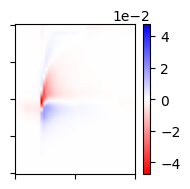

In [28]:
fig, axes = plt.subplots(1,1,figsize=(2,2))
plotFig(axes,spikeCsd)